In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 200

%matplotlib inline

ModuleNotFoundError: No module named 'numpy'

In [ ]:
df = pd.read_csv(r'..\AICE\data\california.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
na_cond = df.isna().any(axis=1)
df[na_cond].head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY


In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [ ]:
df.describe(include='all').round(2).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20433.0,NaN,NaN,NaN,-119.57,2.0,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20433.0,NaN,NaN,NaN,35.63,2.14,32.54,33.93,34.26,37.72,41.95
housing_median_age,20433.0,NaN,NaN,NaN,28.63,12.59,1.0,18.0,29.0,37.0,52.0
total_rooms,20433.0,NaN,NaN,NaN,2636.5,2185.27,2.0,1450.0,2127.0,3143.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.87,421.39,1.0,296.0,435.0,647.0,6445.0
population,20433.0,NaN,NaN,NaN,1424.95,1133.21,3.0,787.0,1166.0,1722.0,35682.0
households,20433.0,NaN,NaN,NaN,499.43,382.3,1.0,280.0,409.0,604.0,6082.0
median_income,20433.0,NaN,NaN,NaN,3.87,1.9,0.5,2.56,3.54,4.74,15.0
median_house_value,20433.0,NaN,NaN,NaN,206864.41,115435.67,14999.0,119500.0,179700.0,264700.0,500001.0
ocean_proximity,20433,5,<1H OCEAN,9034,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

has_nan = pd.isna(df).any()
print(has_nan)

print(f'X.shape: {X.shape}')
print(f'y.shape: {y.shape}')

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
total_bedrooms        False
population            False
households            False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool
X.shape: (20433, 9)
y.shape: (20433,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

X_train: (16346, 9)
X_test: (4087, 9)
y_train: (16346,)
y_test: (4087,)


In [ ]:
from sklearn.preprocessing import OneHotEncoder

oh = OneHotEncoder(dtype=int, handle_unknown='ignore', sparse_output=False)

# The approach below could cause different column names if one has ones the other doesn't have
# Therefore, it is safer to use OneHotEncoder()
# X_train = pd.get_dummies(data=X_train, drop_first=True, dtype=int)
# X_test = pd.get_dummies(data=X_test, drop_first=True, dtype=int)

X_train_enc = oh.fit_transform(X_train[['ocean_proximity']])
X_test_enc = oh.transform(X_test[['ocean_proximity']])

X_train_enc_p = pd.DataFrame(
    X_train_enc,
    columns=oh.get_feature_names_out(['ocean_proximity']),
    index=X_train.index
)

X_test_enc_p = pd.DataFrame(
    X_test_enc,
    columns=oh.get_feature_names_out(['ocean_proximity']),
    index=X_test.index
)

num_cols = X_test.columns
num_cols = num_cols = X_train.columns.drop('ocean_proximity')
print(num_cols)

X_train_enc_f = pd.concat([X_train[num_cols], X_train_enc_p], axis=1)
X_test_enc_f = pd.concat([X_test[num_cols], X_test_enc_p], axis=1)

print(X_train_enc_f.shape)
print(X_test_enc_f.shape)

print(X_train_enc_f.isna().any())
print(X_test_enc_f.isna().any())

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')
(16346, 13)
(4087, 13)
longitude                     False
latitude                      False
housing_median_age            False
total_rooms                   False
total_bedrooms                False
population                    False
households                    False
median_income                 False
ocean_proximity_<1H OCEAN     False
ocean_proximity_INLAND        False
ocean_proximity_ISLAND        False
ocean_proximity_NEAR BAY      False
ocean_proximity_NEAR OCEAN    False
dtype: bool
longitude                     False
latitude                      False
housing_median_age            False
total_rooms                   False
total_bedrooms                False
population                    False
households                    False
median_income                 False
ocean_proximity_<1H OCEAN     False
ocean_proxi

In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train_ss = ss.fit_transform(X_train_enc_f)
X_test_ss = ss.transform(X_test_enc_f)

print(X_train_ss.shape)
print(X_test_ss.shape)

(16346, 13)
(4087, 13)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_ss, y_train)

weights = model.coef_
print(weights)

[-54222.92202624 -54710.01903208  13179.69139329 -12570.97597458
  43114.40773526 -41605.55086031  15935.56568786  74525.13691538
   6068.37657135 -12489.52889074   2849.07138119   2726.03387672
   5610.62459651]


In [ ]:
X_test_ss.shape

has_nan = np.isnan(X_test_ss).sum()
print(has_nan)


has_nan1 = X_test_ss[X_test_ss is np.nan]

has_nan1

# idx = np.arange(0, X_test_ss.size)

# test_df = pd.DataFrame(index=idx, data=X_test_ss)
# test_df_nan = test_df.isna()

0


array([], shape=(0, 4087, 13), dtype=float64)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

y_pred = model.predict(X_test_ss)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

original_attempt = np.array([mae, mse, rmse, r2])

print(f'mae: {mae}')
print(f'mse: {mse}')
print(f'rmse: {rmse}')
print(f'r2 score: {r2}')

mae: 49889.06401685739
mse: 4771095788.134219
rmse: 69073.1191429359
r2 score: 0.6446496847502992


In [ ]:
coef_df = pd.DataFrame({'feature' : X_train_enc_f.columns, 'weights' : model.coef_}).sort_values(by='weights', ascending=False)
coef_df

,feature,weights
7,median_income,74525.136915
4,total_bedrooms,43114.407735
6,households,15935.565688
2,housing_median_age,13179.691393
8,ocean_proximity_<1H OCEAN,6068.376571
12,ocean_proximity_NEAR OCEAN,5610.624597
10,ocean_proximity_ISLAND,2849.071381
11,ocean_proximity_NEAR BAY,2726.033877
9,ocean_proximity_INLAND,-12489.528891
3,total_rooms,-12570.975975


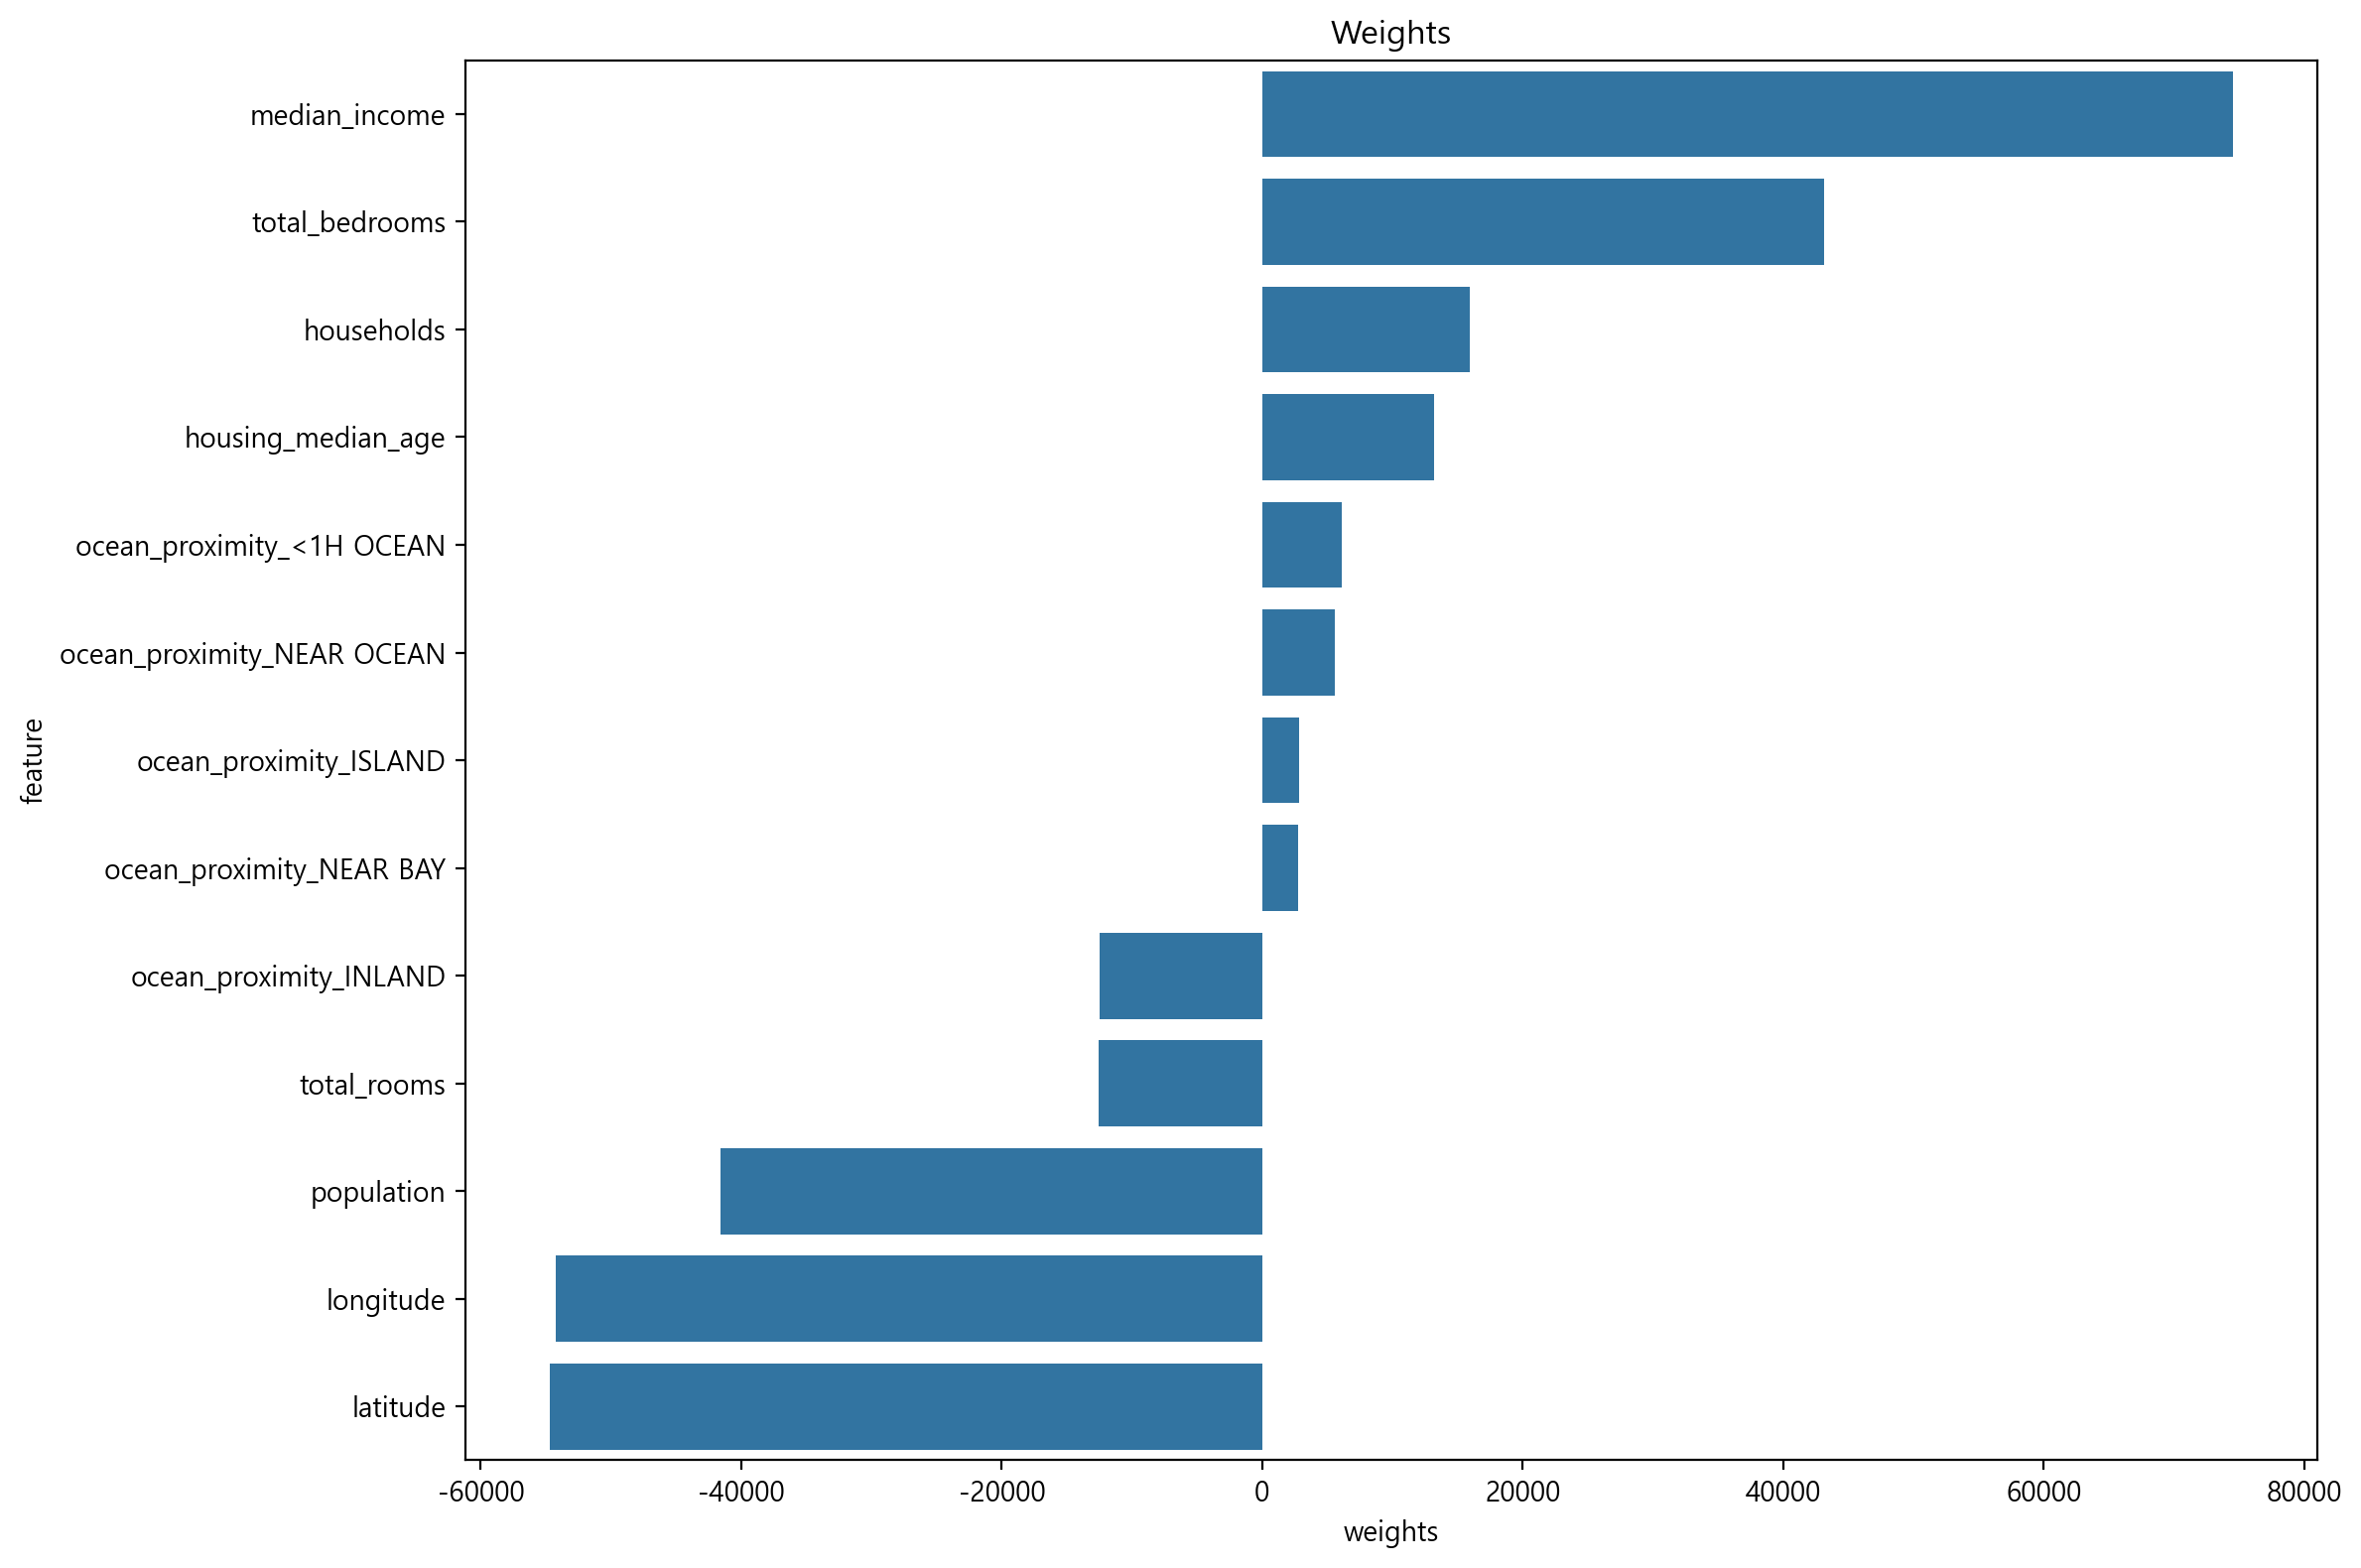

In [ ]:
# sns.heatmap(data=coef_df, cmap='coolwarm', cbar=True, annot=True, fmt=%.2ft%%)
plt.figure(figsize=(12, 8))
sns.barplot(x=coef_df['weights'], y=coef_df['feature'])
plt.title('Weights')

plt.tight_layout()
plt.show()

In [ ]:
df_enh = df.drop(columns=['population', 'longitude', 'latitude'])
df_enh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  20433 non-null  float64
 1   total_rooms         20433 non-null  float64
 2   total_bedrooms      20433 non-null  float64
 3   households          20433 non-null  float64
 4   median_income       20433 non-null  float64
 5   median_house_value  20433 non-null  float64
 6   ocean_proximity     20433 non-null  object 
dtypes: float64(6), object(1)
memory usage: 1.2+ MB


In [ ]:
df_enh.head()

,housing_median_age,total_rooms,total_bedrooms,households,median_income,median_house_value,ocean_proximity
0,41.0,880.0,129.0,126.0,8.3252,452600.0,NEAR BAY
1,21.0,7099.0,1106.0,1138.0,8.3014,358500.0,NEAR BAY
2,52.0,1467.0,190.0,177.0,7.2574,352100.0,NEAR BAY
3,52.0,1274.0,235.0,219.0,5.6431,341300.0,NEAR BAY
4,52.0,1627.0,280.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df_enh.describe(include='all').round(2)

,housing_median_age,total_rooms,total_bedrooms,households,median_income,median_house_value,ocean_proximity
count,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433
unique,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,9034
mean,28.63,2636.50,537.87,499.43,3.87,206864.41,NaN
std,12.59,2185.27,421.39,382.30,1.90,115435.67,NaN
min,1.00,2.00,1.00,1.00,0.50,14999.00,NaN
25%,18.00,1450.00,296.00,280.00,2.56,119500.00,NaN
50%,29.00,2127.00,435.00,409.00,3.54,179700.00,NaN
75%,37.00,3143.00,647.00,604.00,4.74,264700.00,NaN


In [ ]:
df_enh.isna().any()

housing_median_age    False
total_rooms           False
total_bedrooms        False
households            False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool

In [ ]:
num_cols = df_enh.select_dtypes(include='number').columns
cat_cols = df_enh.drop(columns=num_cols).columns
cat_cols

Index(['ocean_proximity'], dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

X = df_enh.drop(columns=['median_house_value'])
y = df_enh['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

X_train_enc = ohe.fit_transform(X_train[cat_cols])
X_test_enc = ohe.transform(X_test[cat_cols])

X_train_enc_f = pd.concat([X_train, X_train_enc], axis=1).drop(columns=['ocean_proximity'])
X_test_enc_f = pd.concat([X_test, X_test_enc], axis=1).drop(columns=['ocean_proximity'])

print(X_train_enc_f.columns)
print(X_test_enc_f.columns)
print()
print(X_train_enc_f.shape)
print(X_test_enc_f.shape)
print()
print(X_train_enc_f.isna().any().sum())
print(X_test_enc_f.isna().any().sum())


Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'households',
       'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')
Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'households',
       'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

(16346, 10)
(4087, 10)

0
0


In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler().set_output(transform="pandas")

X_train_ss = ss.fit_transform(X_train.drop(columns='ocean_proximity'))
X_test_ss = ss.transform(X_test.drop(columns='ocean_proximity'))

X_train_f = pd.concat([X_train_ss, X_train_enc], axis=1)
X_test_f = pd.concat([X_test_ss, X_test_enc], axis=1)

print(X_train_f.columns)
print(X_test_f.columns)
print()
print(X_train_f.shape)
print(X_test_f.shape)
print()
print(X_train_f.isna().any().sum())
print(X_test_f.isna().any().sum())

Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'households',
       'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')
Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'households',
       'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

(16346, 10)
(4087, 10)

0
0


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_f, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

y_pred = model.predict(X_test_f)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

sec_attempt = np.array([mae, mse, rmse, r2])

print(f'mae:{mae}')
print(f'mse:{mse}')
print(f'rmse:{rmse}')
print(f'r2:{r2}')

mae:53460.53429883325
mse:5641359541.856914
rmse:75108.98442834195
r2:0.5857385560065872


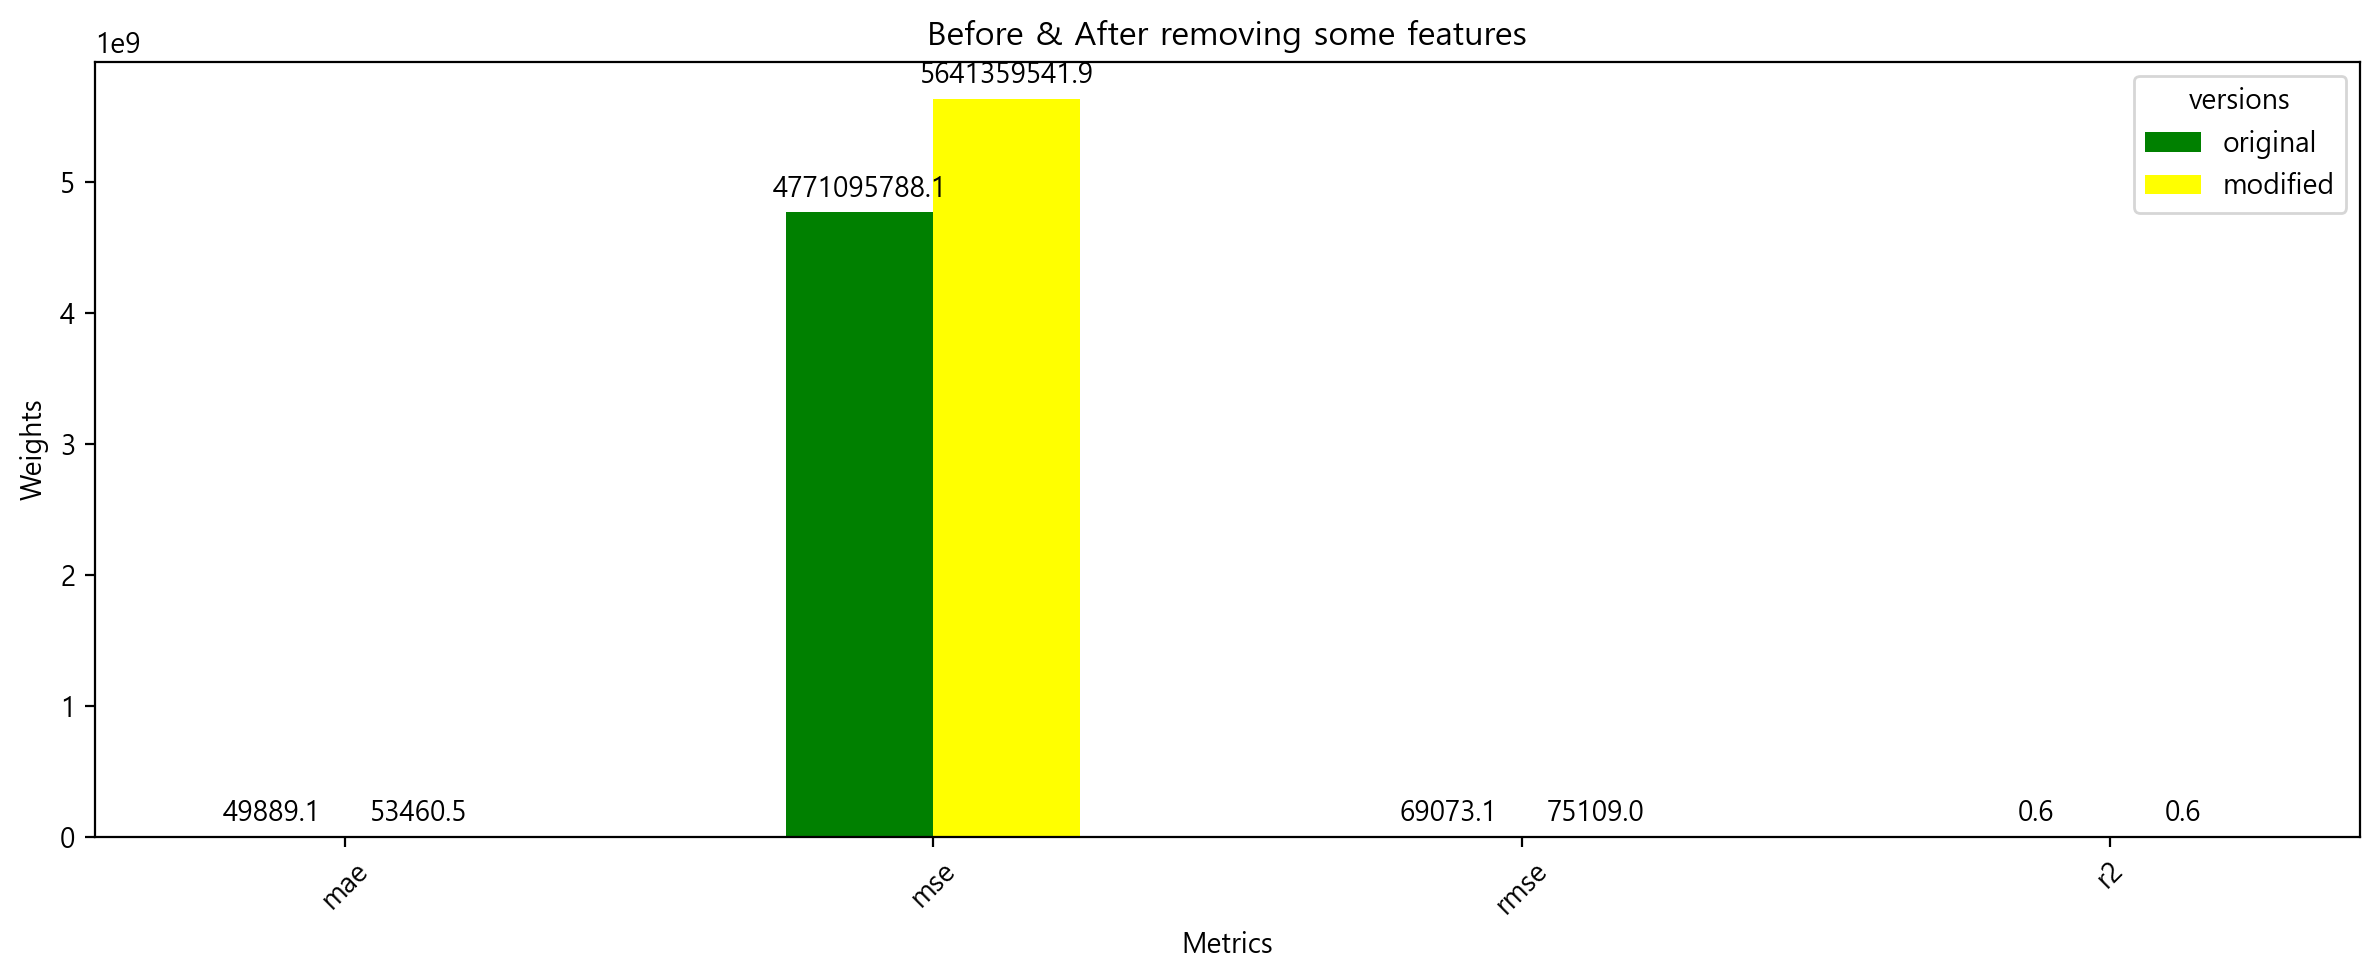

In [ ]:
metrics = ['mae', 'mse', 'rmse', 'r2']
version = ['original', 'modified']

metrics_df = pd.DataFrame({
    version[0]: original_attempt,
    version[1] : sec_attempt
    })

plt.figure(figsize=(12, 5))

x = np.arange(len(metrics))
width = 0.25

bar1 = plt.bar(x - width/2, metrics_df[version[0]], width, label=version[0], color='green')
bar2 = plt.bar(x + width/2, metrics_df[version[1]], width, label=version[1], color='yellow')

plt.bar_label(bar1, fmt='%.1f', padding=3)
plt.bar_label(bar2, fmt='%.1f', padding=3)



plt.title('Before & After removing some features')
plt.xlabel('Metrics')
plt.xticks(x, metrics, rotation=45)
plt.ylabel('Weights')
plt.legend(title='versions')

plt.tight_layout()
plt.show()

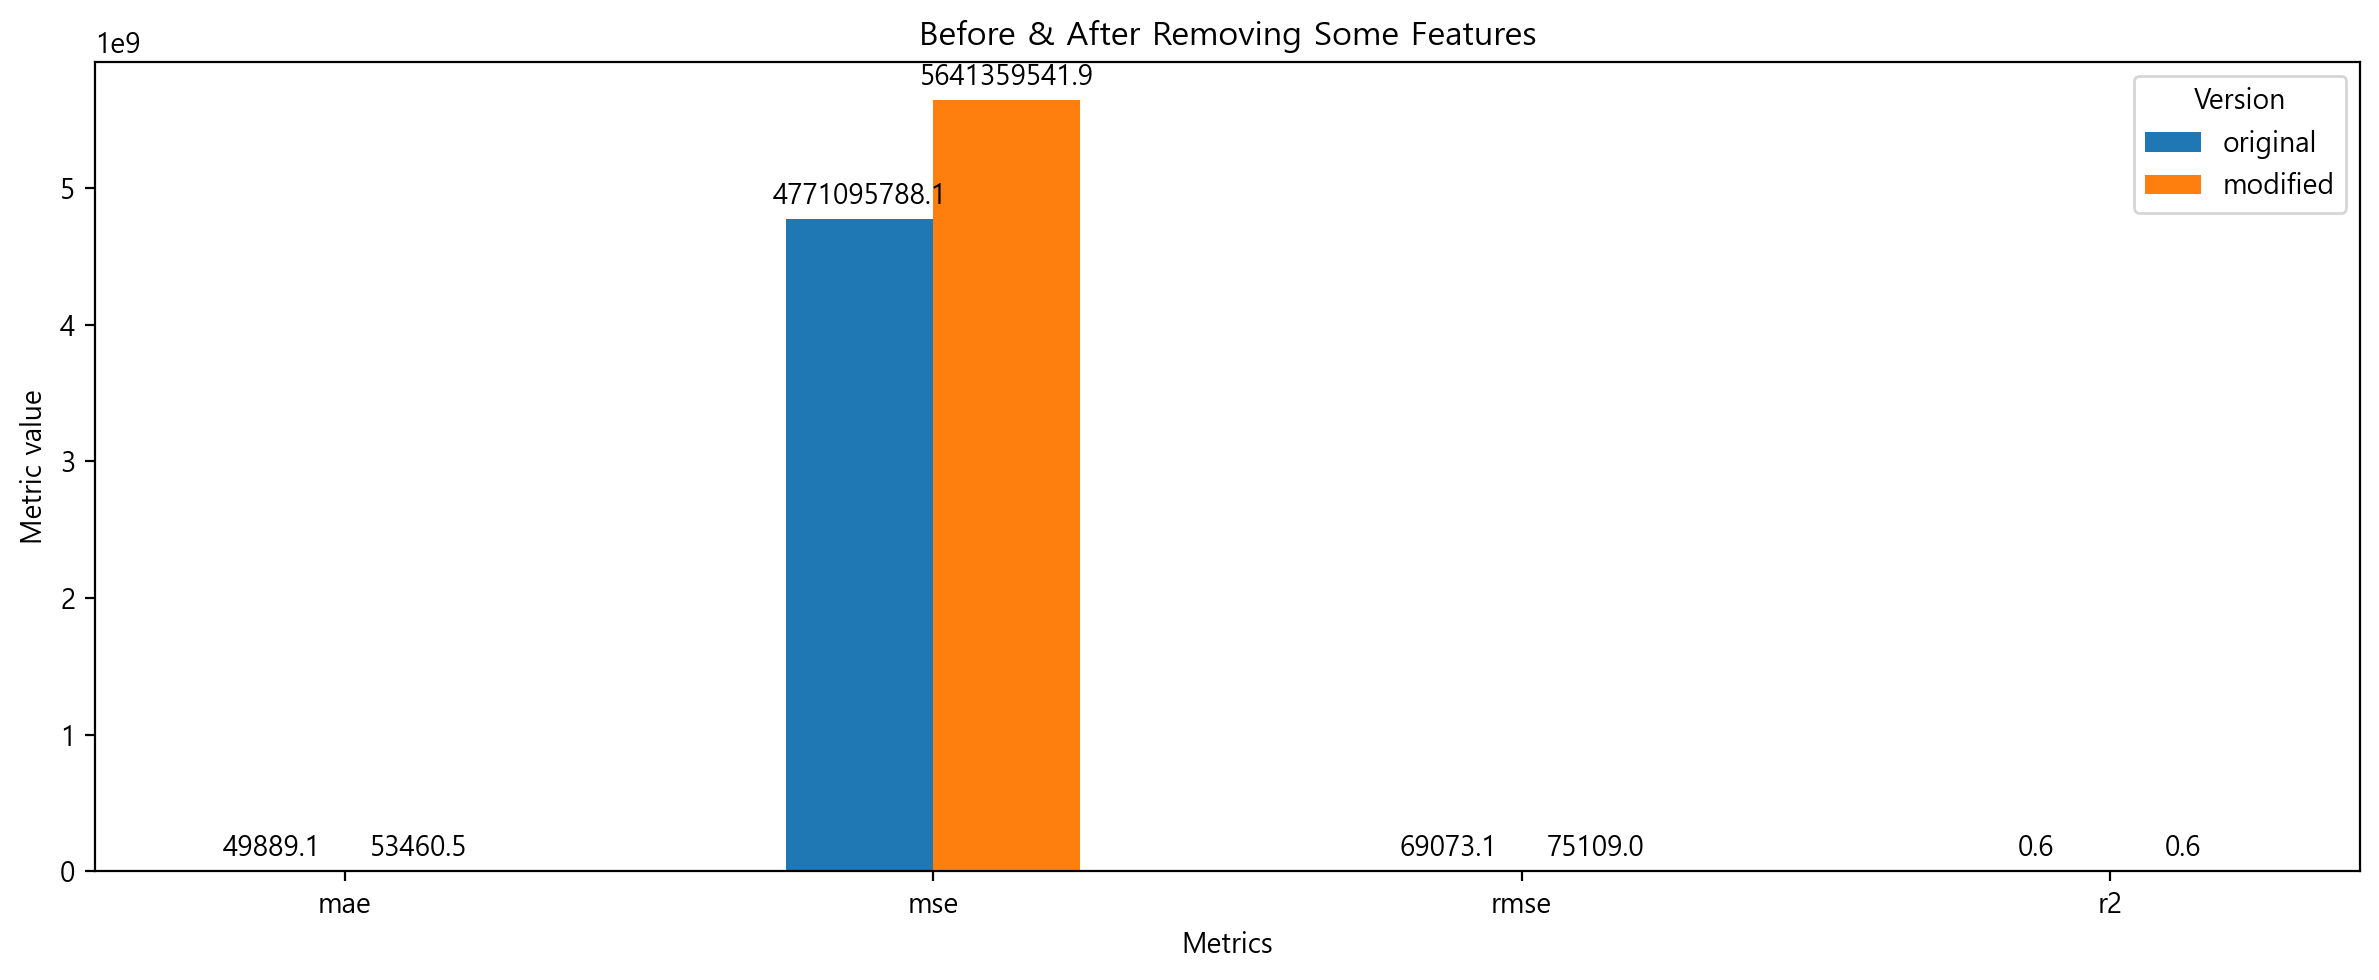

In [ ]:
metrics = ['mae', 'mse', 'rmse', 'r2']
versions = ['original', 'modified']

metrics_df = pd.DataFrame({
    versions[0]: original_attempt,
    versions[1]: sec_attempt
})

plt.figure(figsize=(12, 5))

x = np.arange(len(metrics))
width = 0.25

colors = {
    'original': 'tab:blue',
    'modified': 'tab:orange'
}

bars1 = plt.bar(
    x - width / 2,
    metrics_df[versions[0]],
    width,
    label=versions[0],
    color=colors['original']
)

bars2 = plt.bar(
    x + width / 2,
    metrics_df[versions[1]],
    width,
    label=versions[1],
    color=colors['modified']
)

plt.bar_label(bars1, fmt='%.1f', padding=3)
plt.bar_label(bars2, fmt='%.1f', padding=3)

plt.title('Before & After Removing Some Features')
plt.xlabel('Metrics')
plt.xticks(x, metrics)
plt.ylabel('Metric value')
plt.legend(title='Version')

plt.tight_layout()
plt.show()

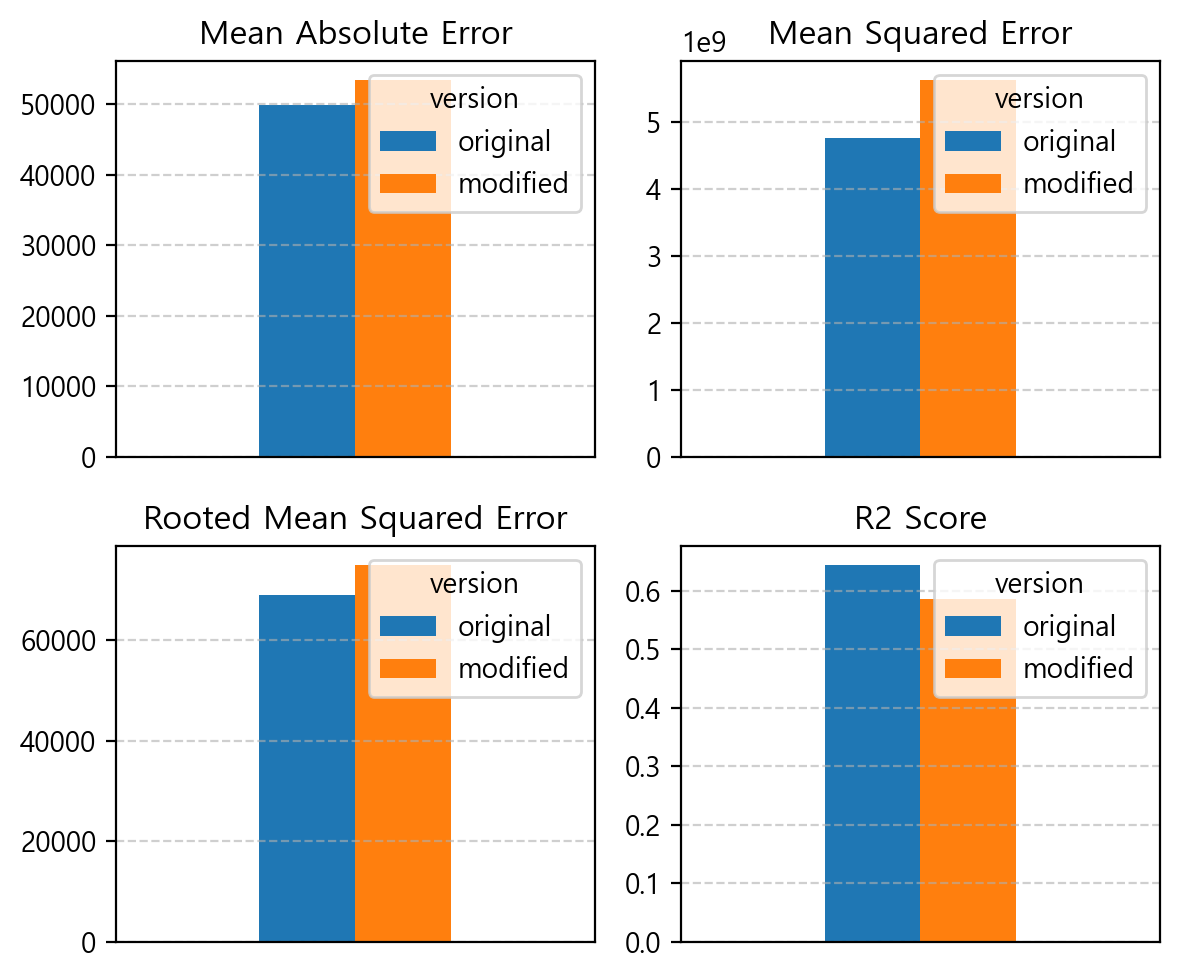

In [ ]:
plt.figure(figsize=(6, 5))

width = 0.3
positions = [-width / 2, width / 2]

plt.subplot(2, 2, 1)
plt.title('Mean Absolute Error')
plt.bar(positions[0], original_attempt[0], width=width, label='original')
plt.bar(positions[1], sec_attempt[0], width=width, label='modified')
plt.xlim(-0.75, 0.75)
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='version')

plt.subplot(2, 2, 2)
plt.title('Mean Squared Error')
plt.bar(positions[0], height=original_attempt[1], width=width, label='original')
plt.bar(positions[1], height=sec_attempt[1], width=width, label='modified')
plt.xlim(-0.75, 0.75)
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='version')

plt.subplot(2, 2, 3)
plt.title('Rooted Mean Squared Error')
plt.bar(positions[0], original_attempt[2], width=width, label='original')
plt.bar(positions[1], sec_attempt[2], width=width, label='modified')
plt.xlim(-0.75, 0.75)
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='version')

plt.subplot(2, 2, 4)
plt.title('R2 Score')
plt.bar(positions[0], original_attempt[3], width=width, label='original')
plt.bar(positions[1], sec_attempt[3], width=width, label='modified')
plt.xlim(-0.75, 0.75)
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='version')

plt.tight_layout()
plt.show()

<Figure size 1200x1200 with 0 Axes>

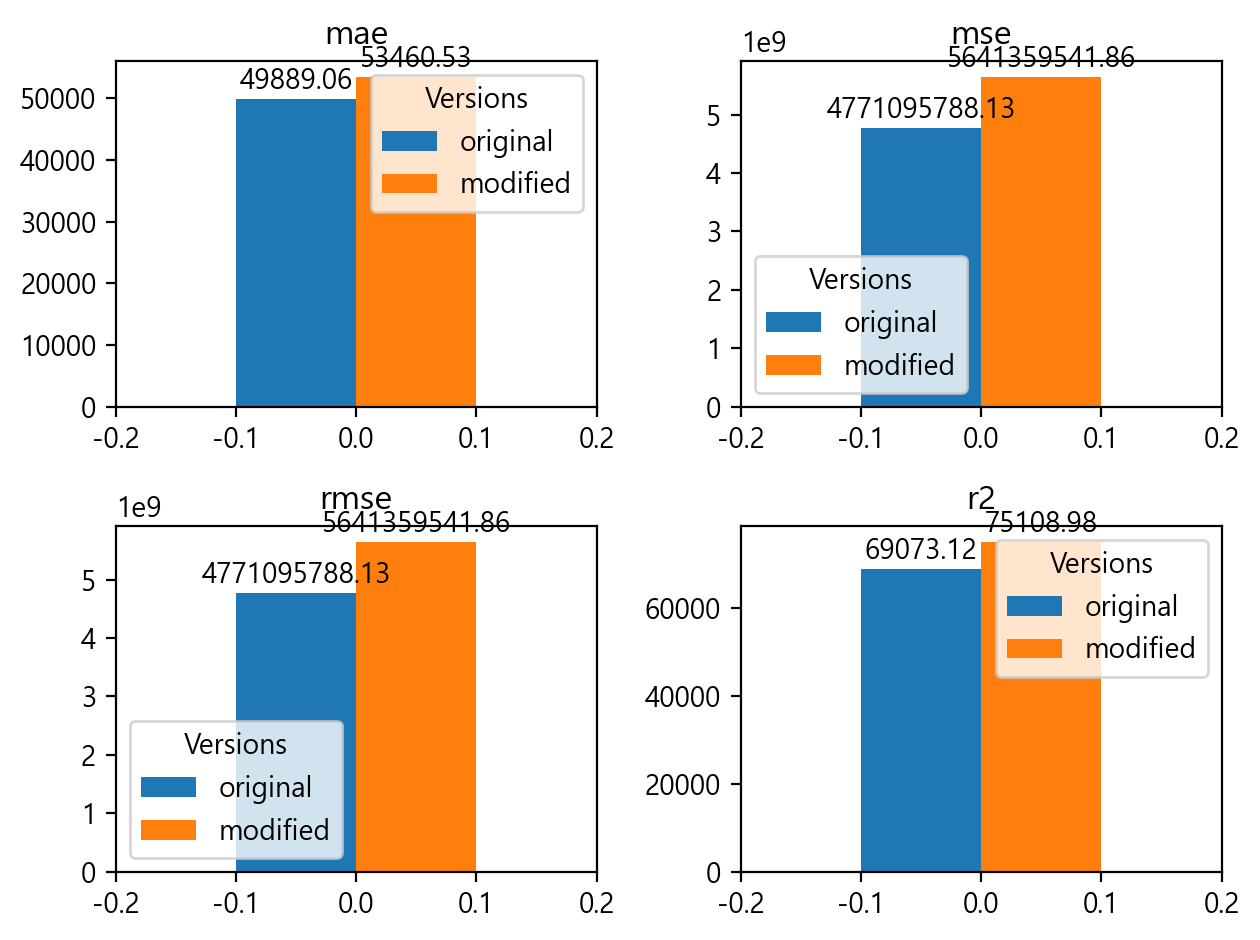

In [ ]:
plt.figure(figsize=(6, 6))

width = 0.1

positions = [- width/2, width/2]

fig, axes = plt.subplots(2, 2)

count = 0
for i in [0, 1]:
    for j in [0, 1]:
        bar_left = axes[i, j].bar(positions[0], original_attempt[i+j], width=width, label=versions[0])
        bar_right = axes[i, j].bar(positions[1], sec_attempt[i+j], width=width, label=versions[1])
        axes[i, j].set_title(metrics[count])
        axes[i, j].set_xlim(-0.2, 0.2)
        axes[i, j].bar_label(bar_left, fmt='%.2f', padding=1)
        axes[i, j].bar_label(bar_right, fmt='%.2f', padding=1)
        axes[i, j].legend(title='Versions')
        count += 1

# bar0_0 = axes[0, 0].bar(positions[0], original_attempt[0], width=width, label='original')
# bar0_1 = axes[0, 0].bar(positions[1], sec_attempt[0], width=width, label='modified')
# axes[0, 0].set_title('Mean Absolute Error')
# axes[0, 0].legend(title='Versions')
# axes[0, 0].bar_label(bar0_0, fmt='%.2f', padding=0)
# axes[0, 0].bar_label(bar0_1, fmt='%.2f', padding=3)
# axes[0, 0].set_xlabel('Version')
# axes[0, 0].set_xlim(-0.2, 0.2)

plt.tight_layout()
plt.show()